# Map Descriptive Analysis Notebook
This notebook includes all the code required for the map visualizations (as seen in the main notebook)

In [18]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

out_dir = "visualizations/descriptive_maps"
os.makedirs(out_dir, exist_ok=True)

from CEStools.utils import clean_data
from CEStools.utils import qmap

In [19]:
shp_path = "data/calenviroscreen40_shp/CES4 Final Shapefile.shp"
shape = gpd.read_file(shp_path)

In [20]:
shape = clean_data(shape, keep_geom=True)
shape = shape.to_crs(epsg=3857)

In [21]:
shape.head()

,CIscoreP,OzoneP,PM2_5_P,DieselPM_P,PesticideP,Tox_Rel_P,TrafficP,DrinkWatP,Lead_P,CleanupP,...,UnemplP,HousBurdP,PopCharP,Hispanic,White,AfricanAm,NativeAm,OtherMult,AAPI,geometry
0,69.162885,10.566273,10.031114,52.408214,92.034483,9.914979,63.4000,11.165230,36.118463,17.077268,...,18.310776,69.150824,79.828543,68.9210,20.8899,0.4004,0.2670,1.3126,8.2091,"POLYGON ((-13406867.885 4155533.339, -13404832..."
1,70.637922,11.561917,10.454263,39.365277,99.586207,10.265066,19.9000,52.828775,43.805923,72.396417,...,69.130661,60.101394,56.555724,78.6229,13.2240,2.5051,0.0000,0.9489,4.6990,"POLYGON ((-13406867.885 4155533.339, -13406867..."
2,61.069087,10.566273,9.931549,60.311139,93.827586,10.515129,42.7500,11.165230,75.072464,2.071669,...,35.020822,53.624842,67.183560,65.7214,30.6088,0.9591,0.0000,2.1685,0.5421,"POLYGON ((-13404824.281 4156507.571, -13404832..."
3,5.988401,13.615432,10.653391,34.275047,95.413793,7.864466,39.9250,32.559011,11.077505,0.000000,...,58.355023,16.311787,10.741301,22.9537,69.1948,0.9342,0.7117,2.5356,3.6699,"POLYGON ((-13403841.327 4147463.306, -13403732..."
4,23.121533,13.615432,10.690728,18.481643,63.241379,7.714429,24.3625,32.559011,49.514808,2.071669,...,92.399792,12.002535,46.280888,33.4082,59.7804,0.6986,1.4721,1.3723,3.2685,"POLYGON ((-13406428.948 4147489.901, -13404941..."


In [22]:
burden = "CIscoreP"

In [23]:
exposure_vars = ["OzoneP", "PM2_5_P", "DieselPM_P", "TrafficP", "Tox_Rel_P", "PesticideP"]
shape["ExposureIdx"] = shape[exposure_vars].mean(axis=1, skipna=True)

--- Hispanic ---


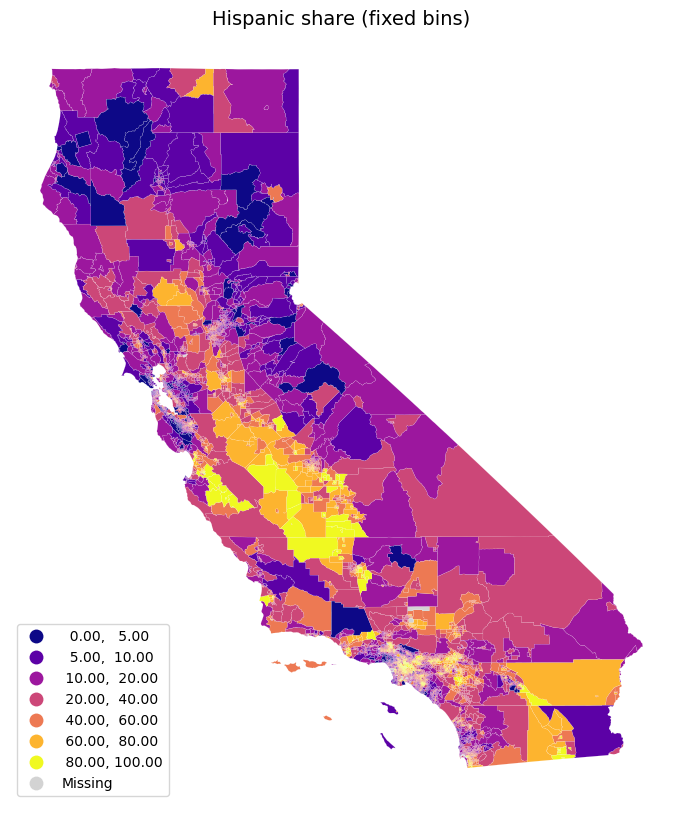

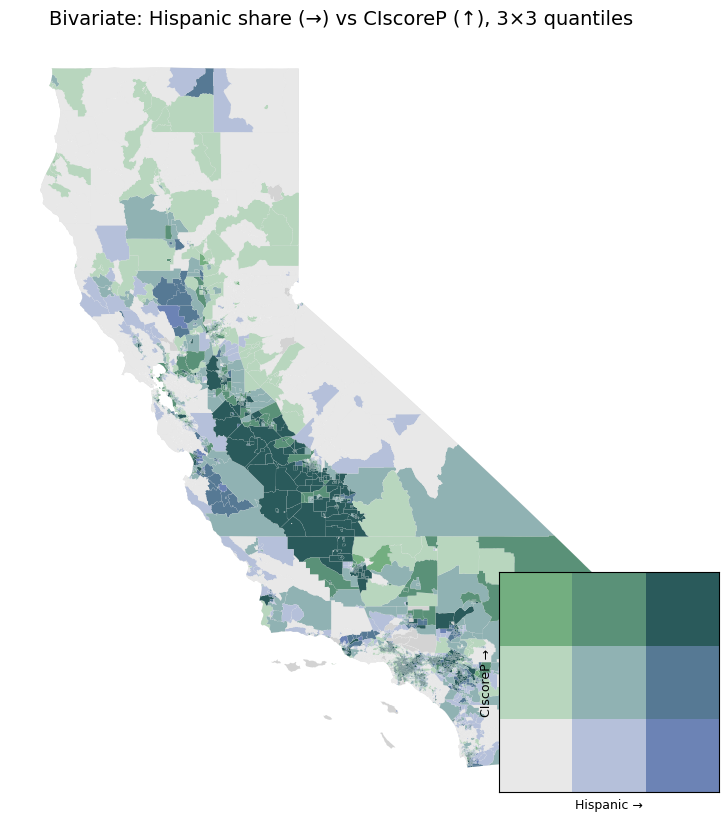

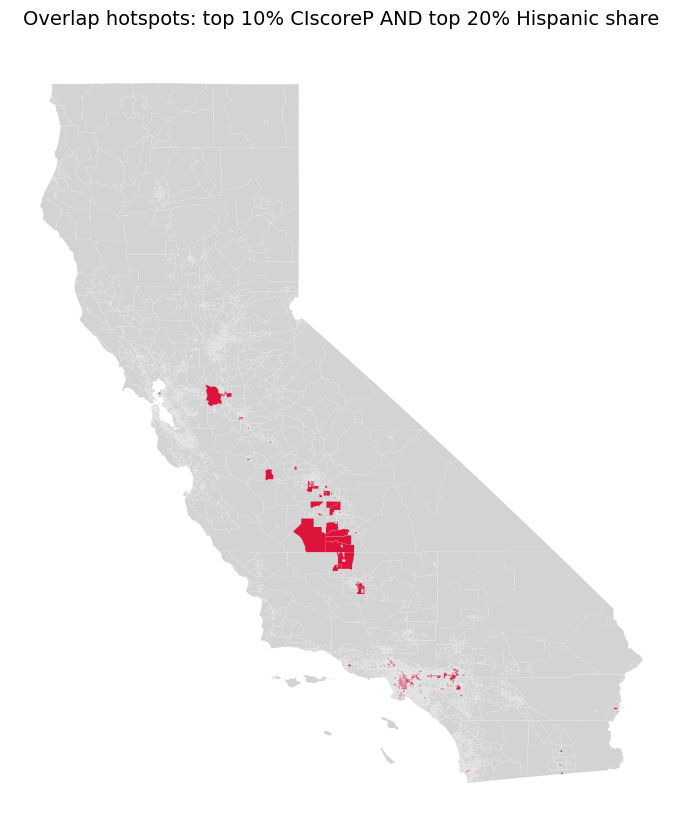

--- White ---


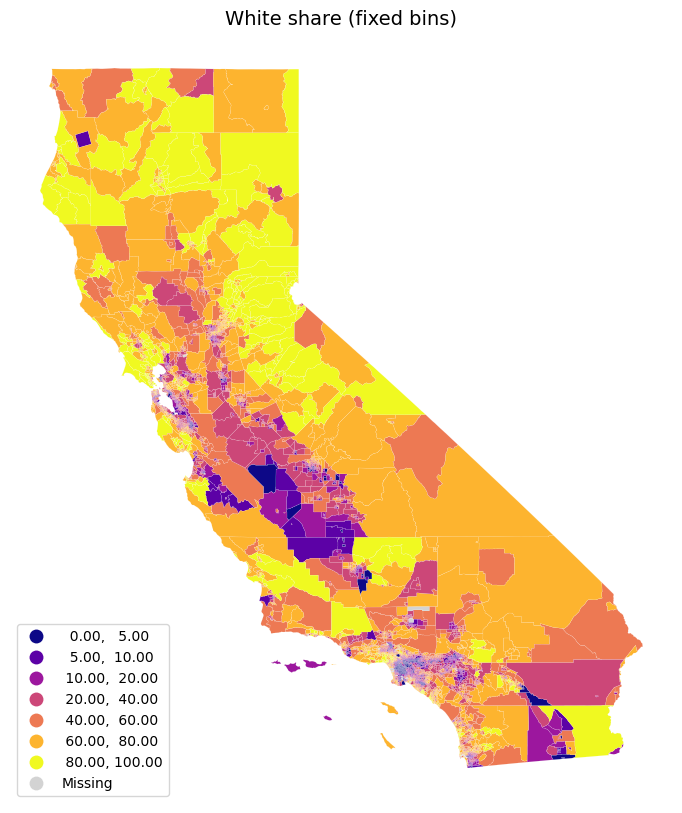

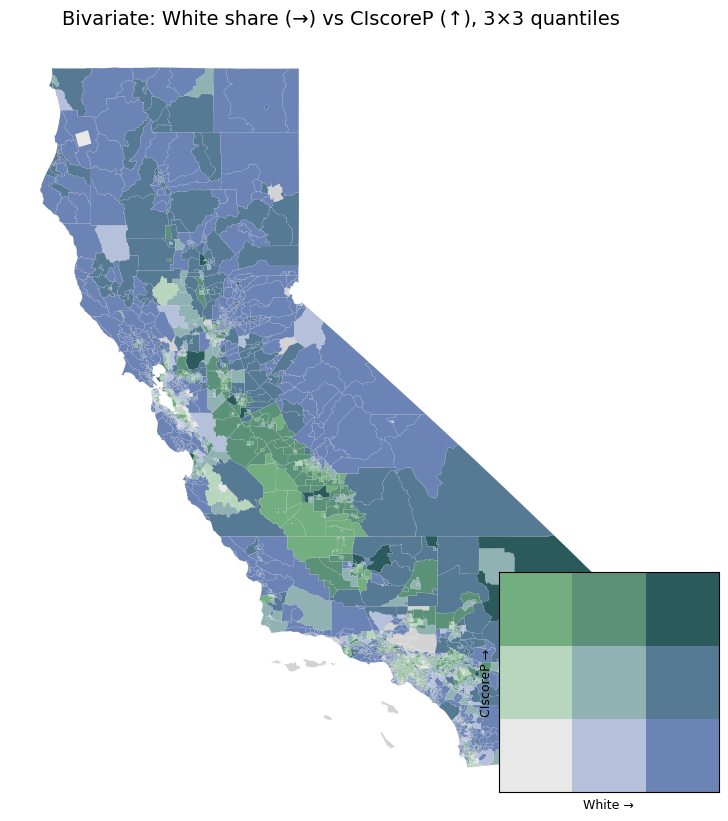

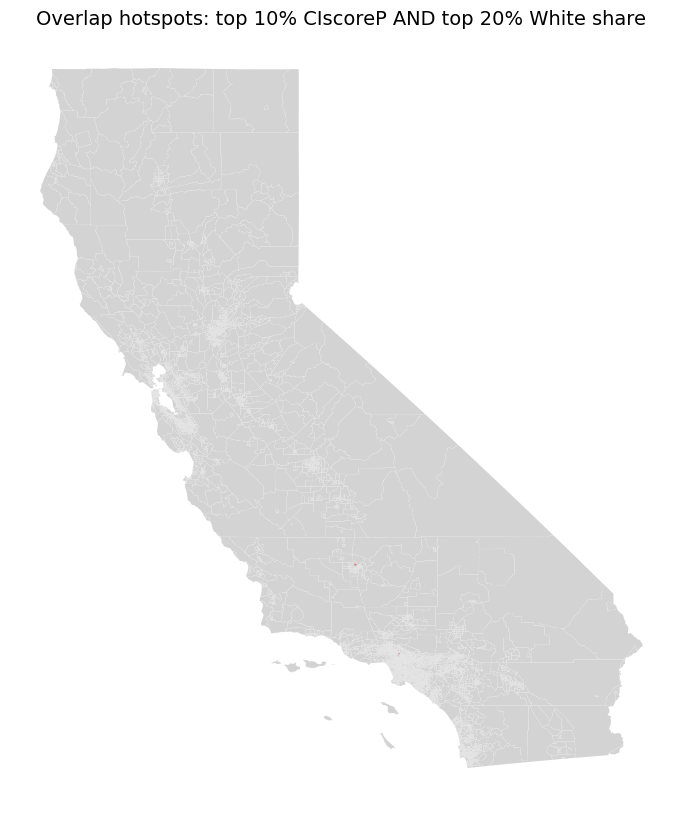

--- AfricanAm ---


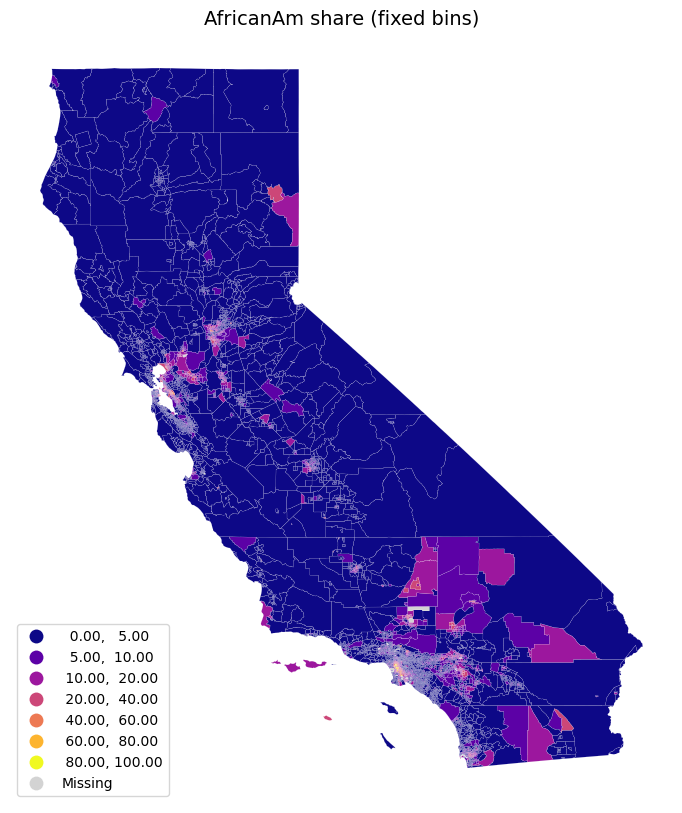

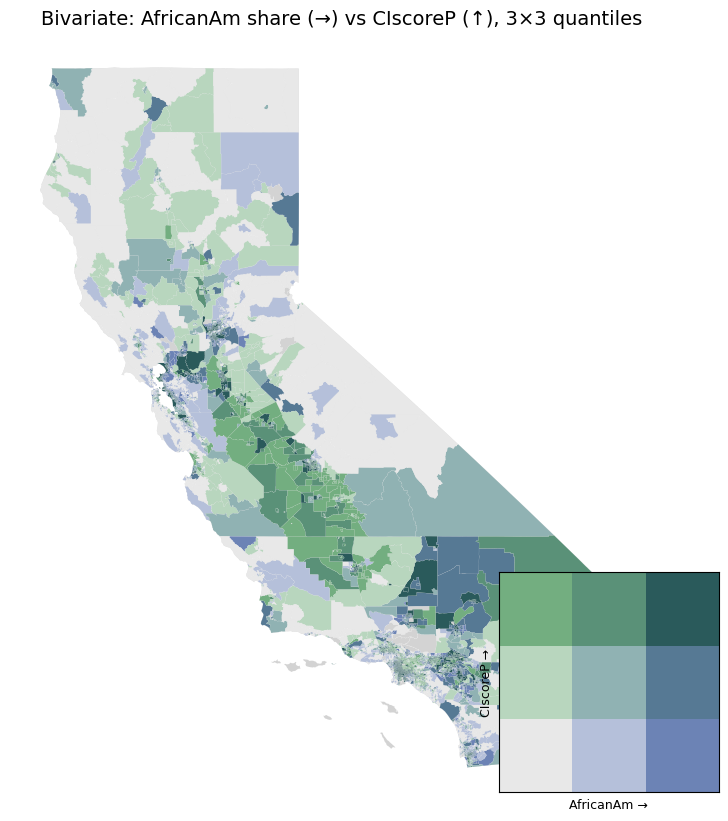

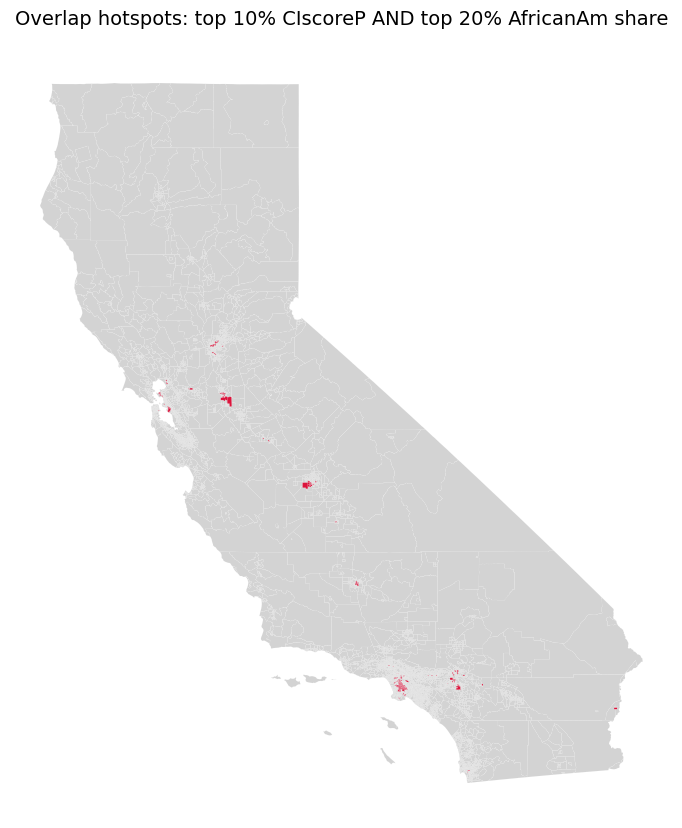

--- NativeAm ---


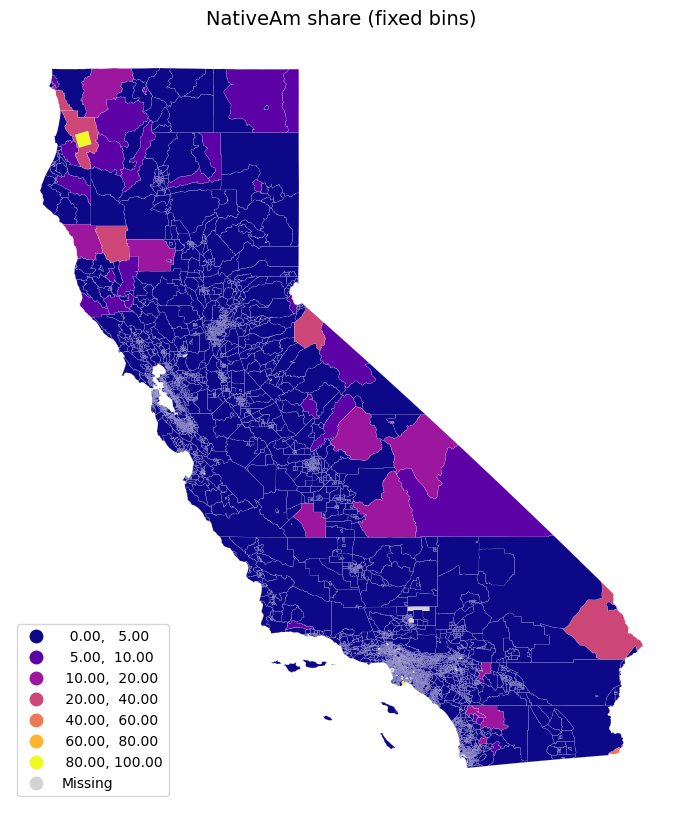

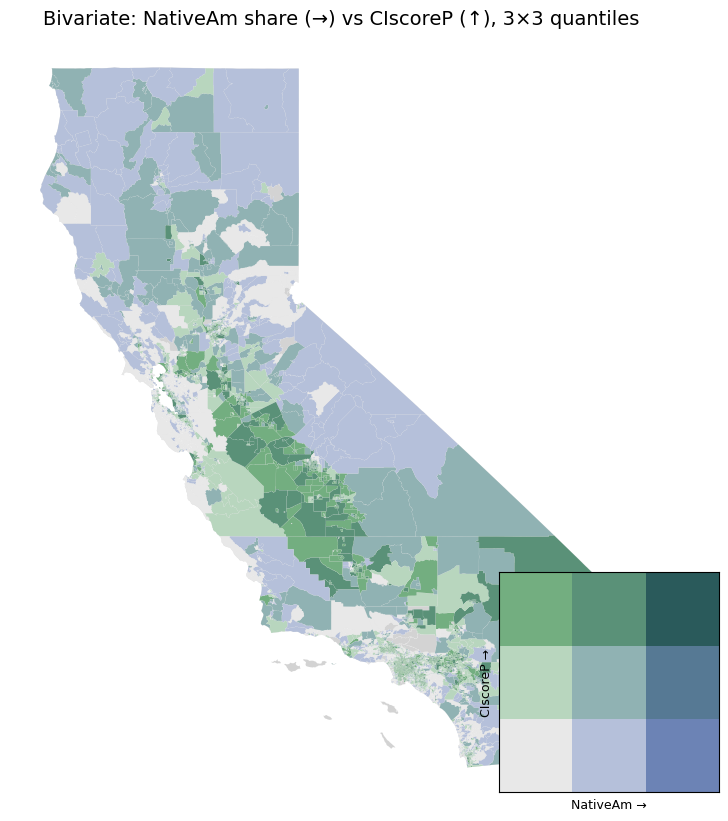

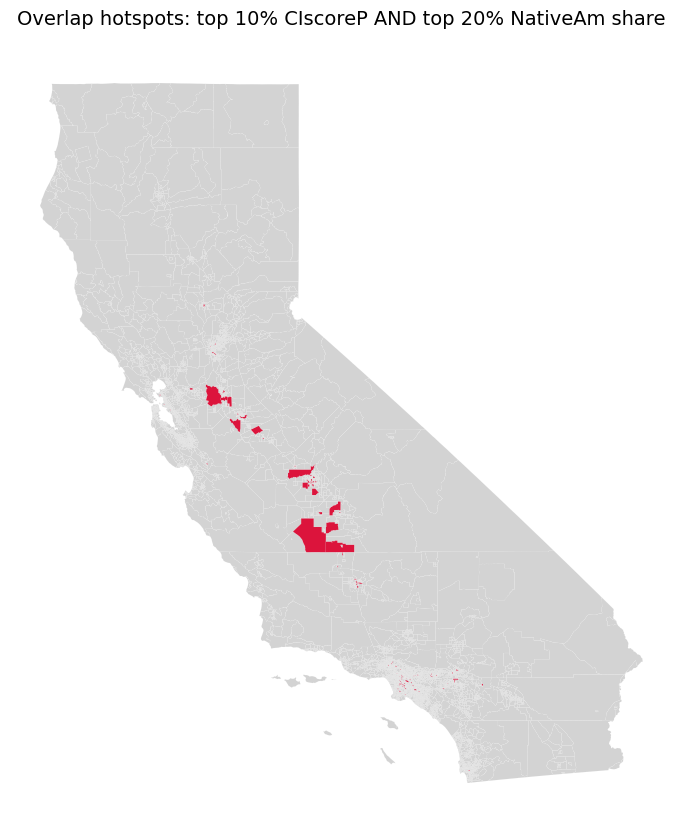

--- OtherMult ---


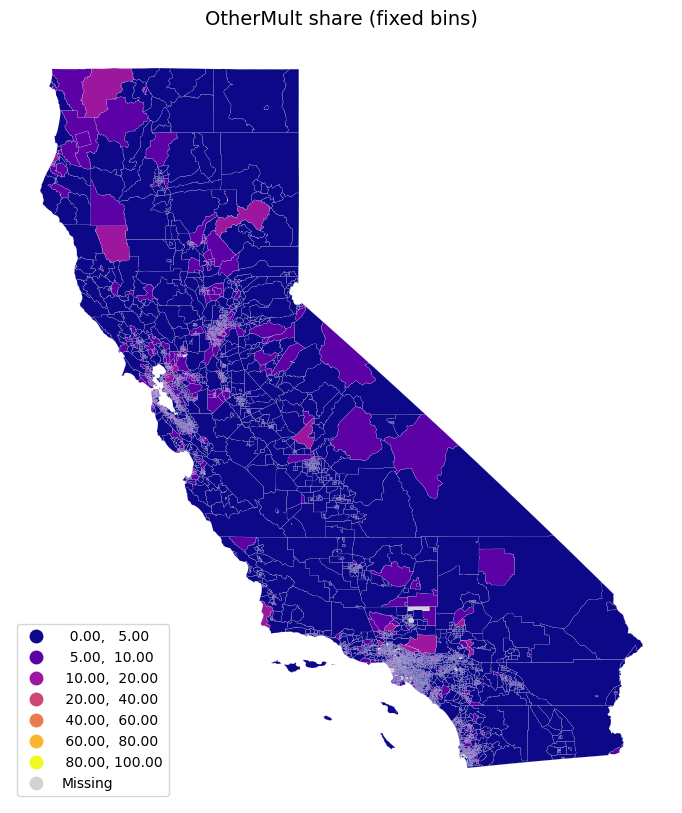

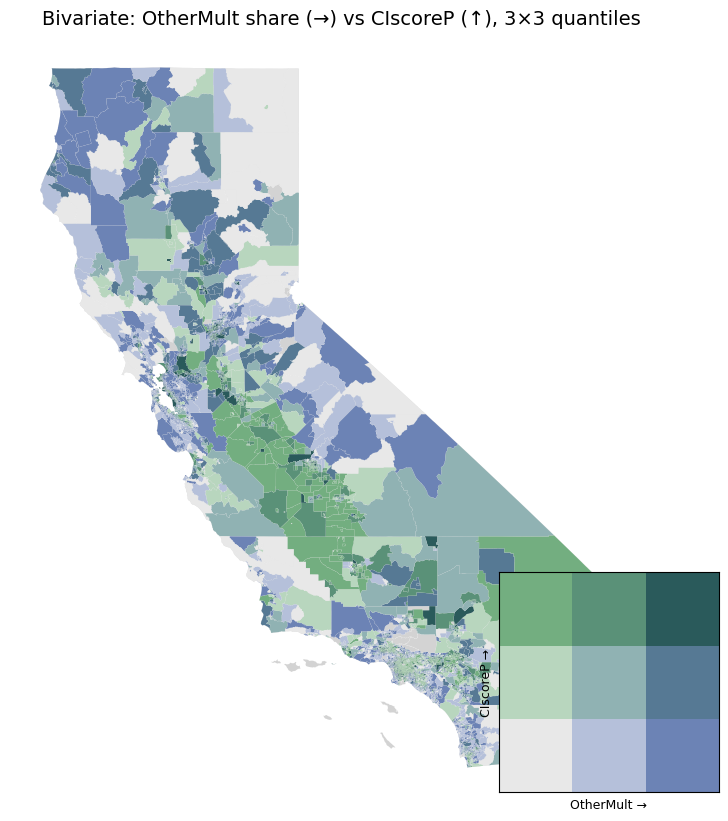

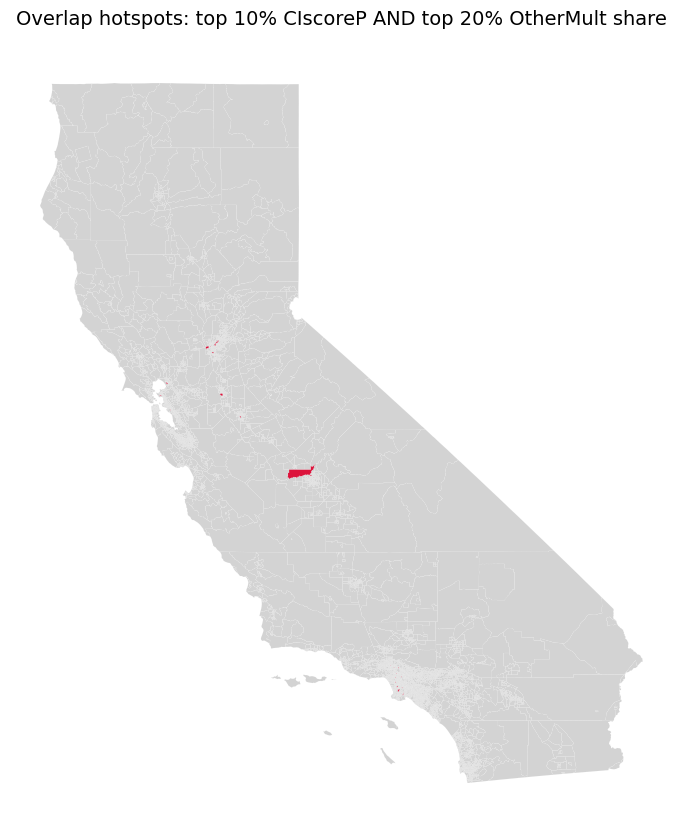

--- AAPI ---


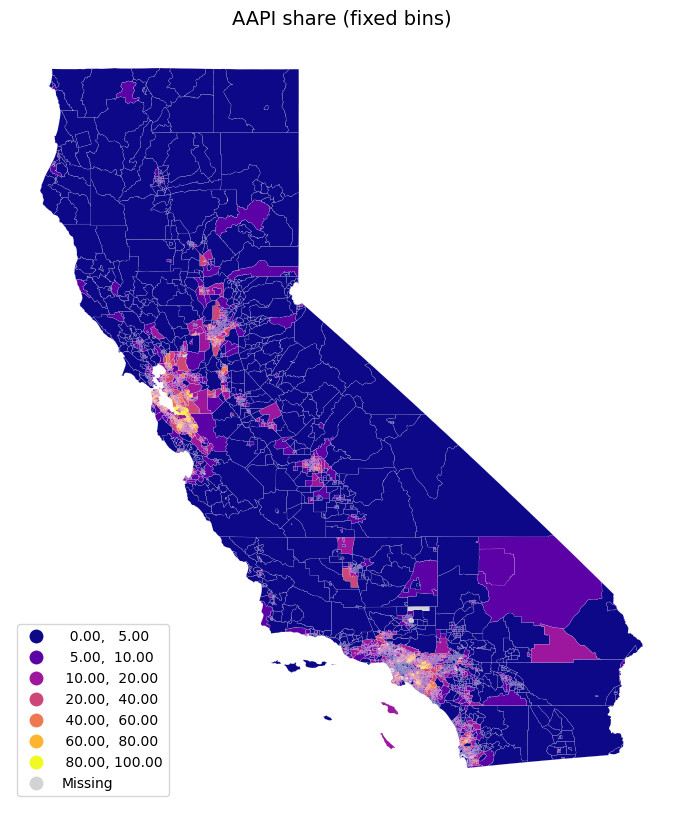

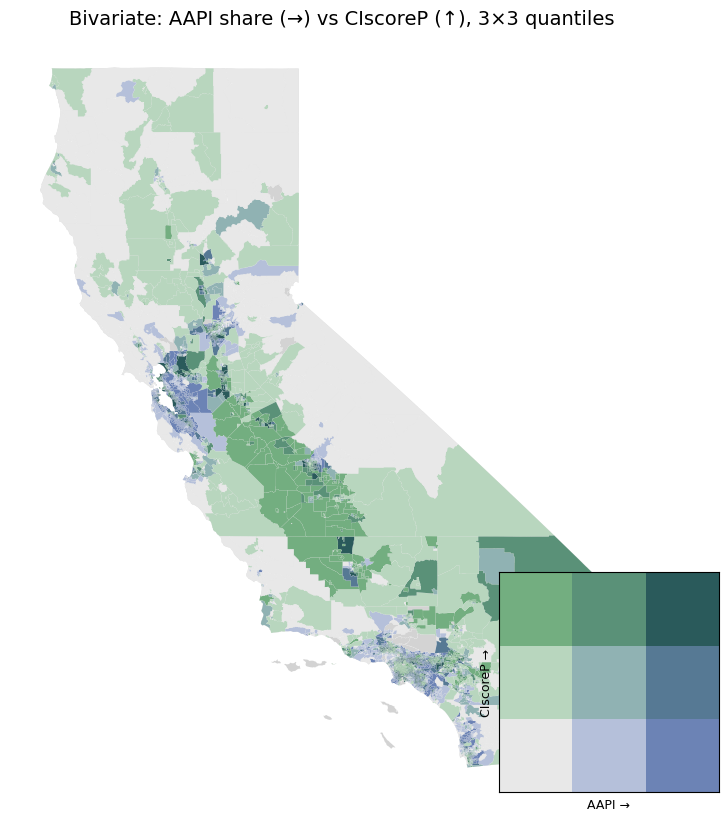

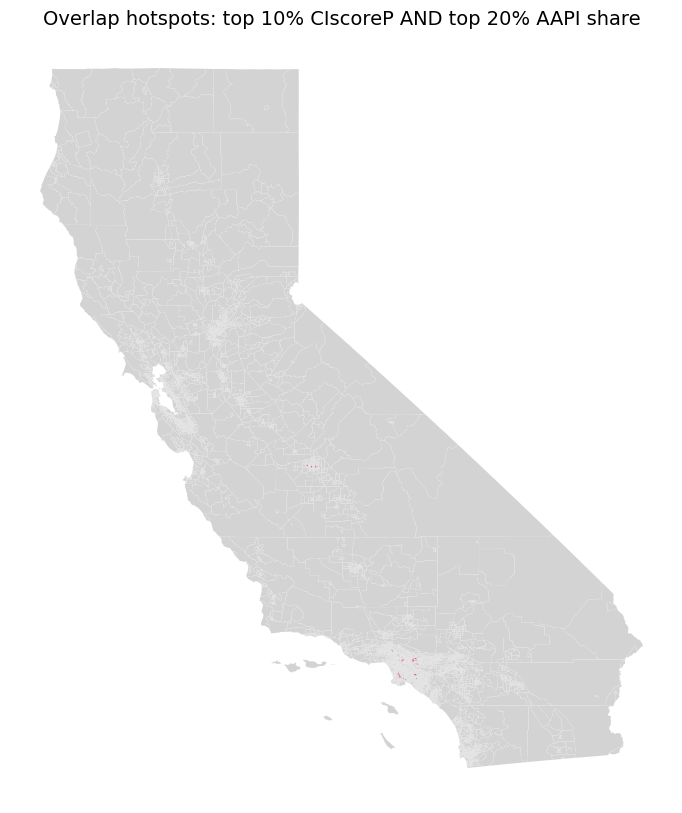

In [24]:
race_cols = ['Hispanic','White','AfricanAm','NativeAm','OtherMult','AAPI']
race_bins = [5, 10, 20, 40, 60, 80, 100]
for race in race_cols:
    print(f"--- {race} ---")

    # 1: Map depicting race share (for each race)
    qmap(
        shape,
        race,
        title=f"{race} share (fixed bins)",
        cmap="plasma",
        bins=race_bins,
        save=f"visualizations/descriptive_maps/race_{race}_fixedbins.png"
    )

    # 2) Bivariate map: race share (x) vs burden (y), 3×3 quantiles

    df = shape[[race, burden, "geometry"]].dropna().copy()

    # quantile bins: 0 = low, 1 = mid, 2 = high
    df["race_bin"] = pd.qcut(df[race], 3, labels=False, duplicates="drop")
    df["burden_bin"] = pd.qcut(df[burden], 3, labels=False, duplicates="drop")

    df["bi"] = df["race_bin"].astype(int) + 3 * df["burden_bin"].astype(int)

    # rows = burden (low to high), cols = race (low to high)
    colors = [
        "#e8e8e8", "#b5c0da", "#6c83b5",   # low burden
        "#b8d6be", "#90b2b3", "#567994",   # mid burden
        "#73ae80", "#5a9178", "#2a5a5b"    # high burden
    ]
    df["color"] = df["bi"].map(lambda i: colors[int(i)])

    fig, ax = plt.subplots(1, 1, figsize=(10,10))
    ax.set_axis_off()

    # base map
    shape.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.05)
    df.plot(ax=ax, color=df["color"], edgecolor="white", linewidth=0.05)

    ax.set_title(
        f"Bivariate: {race} share (→) vs {burden} (↑), 3×3 quantiles",
        fontsize=14
    )

    # legend (3×3 grid)
    leg = fig.add_axes([0.67, 0.12, 0.22, 0.22])
    leg.set_xticks([]); leg.set_yticks([]); leg.set_frame_on(True)

    k = 0
    for j in range(3):          # burden: low -> high
        for i in range(3):      # race: low -> high
            leg.add_patch(
                plt.Rectangle((i, j), 1, 1, facecolor=colors[k], edgecolor="none")
            )
            k += 1

    leg.set_xlim(0, 3); leg.set_ylim(0, 3)
    leg.set_xlabel(f"{race} →", fontsize=9)
    leg.set_ylabel(f"{burden} →", fontsize=9)
    plt.savefig(
        f"visualizations/descriptive_maps/bivariate_{race}_{burden}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # 3) Overlap hotspots: top 10% burden AND top 20% race share
    cut_hi = shape[race].quantile(0.80)
    burden_hot = shape[burden].quantile(0.90)
    overlap = (shape[burden] >= burden_hot) & (shape[race] >= cut_hi)

    fig, ax = plt.subplots(1, 1, figsize=(10,10))
    ax.set_axis_off()
    shape.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.05)
    shape.loc[overlap].plot(ax=ax, color="crimson", edgecolor="white", linewidth=0.05)
    ax.set_title(f"Overlap hotspots: top 10% {burden} AND top 20% {race} share", fontsize=14)
    plt.savefig(
        f"visualizations/descriptive_maps/overlap_hotspots_{race}_{burden}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
